# Modelagem - Modelo de Inferência do Perfil de Aprendizagem (LP)

Este notebook tem como objetivo realizar as etapas de modelagem para o modelo de inferência do perfil de aprendizagem. Isso inclui a seleção de modelos, treinamento, previsão e avaliação inicial.

In [3]:
import pandas as pd
import numpy as np
import os

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

# Set global plotting styles
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 1. Carregamento dos Dados Pré-processados

In [4]:
processed_data_dir = os.path.join('..', 'data', 'processed')

X_train = pd.read_csv(os.path.join(processed_data_dir, 'X_train.csv'))
X_test = pd.read_csv(os.path.join(processed_data_dir, 'X_test.csv'))
y_train = pd.read_csv(os.path.join(processed_data_dir, 'y_train.csv')).squeeze() # .squeeze() para Series
y_test = pd.read_csv(os.path.join(processed_data_dir, 'y_test.csv')).squeeze() # .squeeze() para Series

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train.head()

X_train shape: (1400, 16)
X_test shape: (600, 16)
y_train shape: (1400,)
y_test shape: (600,)


,time_spent_on_video,time_spent_on_audio,time_spent_on_reading,time_spent_on_writing,time_spent_on_quizz,time_spent_on_flashcards,time_spent_on_projects,completed_exercices,completed_quizzes,completed_flashcards,text_quizzes_accuracy,visual_quizzes_accuracy,most_preferred_resource_type_audio,most_preferred_resource_type_practical,most_preferred_resource_type_text,most_preferred_resource_type_video
0,2.270476,-0.649090,-1.408355,-1.438471,0.250127,-0.510243,-1.117158,-1.108688,-0.474216,0.979724,0.631883,0.832509,1.824556,-0.564262,-0.59583,-0.601224
1,-0.607332,0.086798,0.944425,-0.204604,-1.487470,0.251565,0.000420,0.621388,1.613309,1.330911,-0.421649,0.312963,-0.548079,-0.564262,-0.59583,1.663273
2,1.250510,-0.904457,-0.439671,0.862107,0.341996,-1.477881,0.581021,0.621388,1.149415,1.682099,1.290818,0.771774,-0.548079,-0.564262,-0.59583,1.663273
3,-0.425376,0.351214,0.942035,0.143870,1.037364,-0.400540,0.725891,0.188869,0.917467,0.628537,-0.337821,0.335370,-0.548079,1.772226,-0.59583,-0.601224
4,0.806269,0.868960,0.322793,-0.249300,-1.487470,-0.748697,-0.346717,1.198080,0.221626,1.506505,1.661617,-1.042588,-0.548079,-0.564262,-0.59583,1.663273


## 2. Seleção e Treinamento de Modelos Iniciais

In [5]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

trained_models = {}
for name, model in models.items():
    print(f"Treinando {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} treinado com sucesso.")

Treinando Logistic Regression...
Logistic Regression treinado com sucesso.
Treinando Decision Tree...
Decision Tree treinado com sucesso.
Treinando Random Forest...
Random Forest treinado com sucesso.
Treinando XGBoost...


/Users/dionatasantosdasilva/Repos/personal/tcc/tutor-ia-project/tutor-ia-ml/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [16:42:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost treinado com sucesso.


## 3. Previsões e Avaliação dos Modelos

Avaliando Logistic Regression...
Resultados para Logistic Regression:
  Acurácia (Treino): 0.5314
  F1-Score (Treino): 0.5279
  Acurácia (Teste): 0.5467
  F1-Score (Teste): 0.5447
  Relatório de Classificação (Teste):
              precision    recall  f1-score   support

           0       0.56      0.46      0.51       134
           1       0.58      0.64      0.61       141
           2       0.55      0.60      0.58       165
           3       0.49      0.48      0.49       160

    accuracy                           0.55       600
   macro avg       0.55      0.55      0.54       600
weighted avg       0.55      0.55      0.54       600

  Matriz de Confusão (Teste):
[[62 18 24 30]
 [ 8 90 17 26]
 [15 27 99 24]
 [25 19 39 77]]


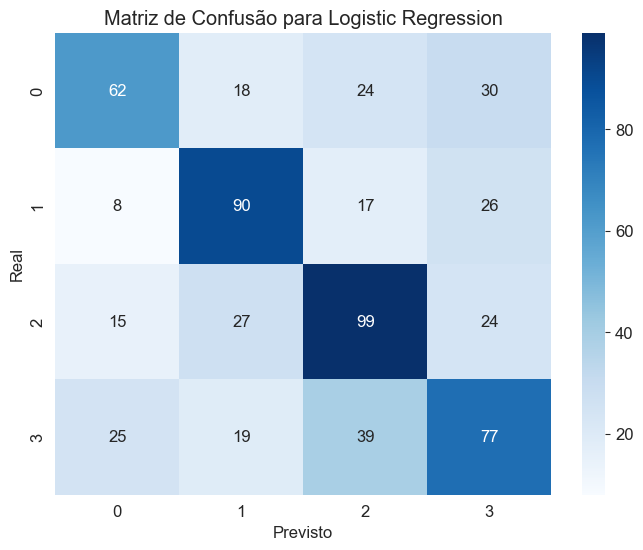

Avaliando Decision Tree...
Resultados para Decision Tree:
  Acurácia (Treino): 1.0000
  F1-Score (Treino): 1.0000
  Acurácia (Teste): 0.4500
  F1-Score (Teste): 0.4471
  Relatório de Classificação (Teste):
              precision    recall  f1-score   support

           0       0.34      0.35      0.35       134
           1       0.62      0.68      0.65       141
           2       0.43      0.38      0.40       165
           3       0.40      0.41      0.40       160

    accuracy                           0.45       600
   macro avg       0.45      0.45      0.45       600
weighted avg       0.45      0.45      0.45       600

  Matriz de Confusão (Teste):
[[47 22 27 38]
 [15 96 11 19]
 [37 25 62 41]
 [38 13 44 65]]


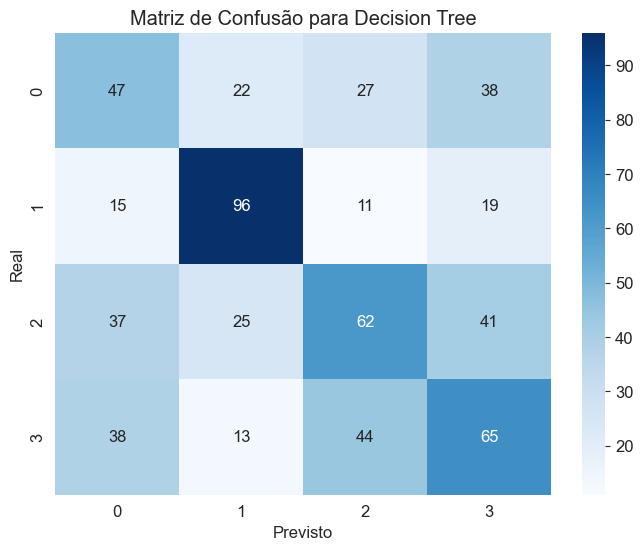

Avaliando Random Forest...
Resultados para Random Forest:
  Acurácia (Treino): 1.0000
  F1-Score (Treino): 1.0000
  Acurácia (Teste): 0.5267
  F1-Score (Teste): 0.5288
  Relatório de Classificação (Teste):
              precision    recall  f1-score   support

           0       0.41      0.37      0.39       134
           1       0.77      0.69      0.73       141
           2       0.53      0.56      0.54       165
           3       0.43      0.48      0.45       160

    accuracy                           0.53       600
   macro avg       0.54      0.52      0.53       600
weighted avg       0.53      0.53      0.53       600

  Matriz de Confusão (Teste):
[[50 11 27 46]
 [ 9 97 18 17]
 [23 10 92 40]
 [39  8 36 77]]


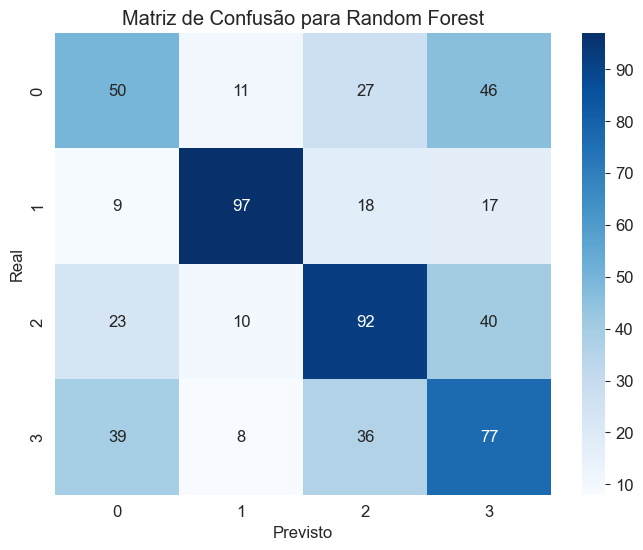

Avaliando XGBoost...
Resultados para XGBoost:
  Acurácia (Treino): 1.0000
  F1-Score (Treino): 1.0000
  Acurácia (Teste): 0.5400
  F1-Score (Teste): 0.5408
  Relatório de Classificação (Teste):
              precision    recall  f1-score   support

           0       0.44      0.41      0.42       134
           1       0.78      0.71      0.74       141
           2       0.52      0.59      0.55       165
           3       0.46      0.45      0.45       160

    accuracy                           0.54       600
   macro avg       0.55      0.54      0.54       600
weighted avg       0.54      0.54      0.54       600

  Matriz de Confusão (Teste):
[[ 55  10  32  37]
 [ 11 100  19  11]
 [ 20  11  97  37]
 [ 40   8  40  72]]


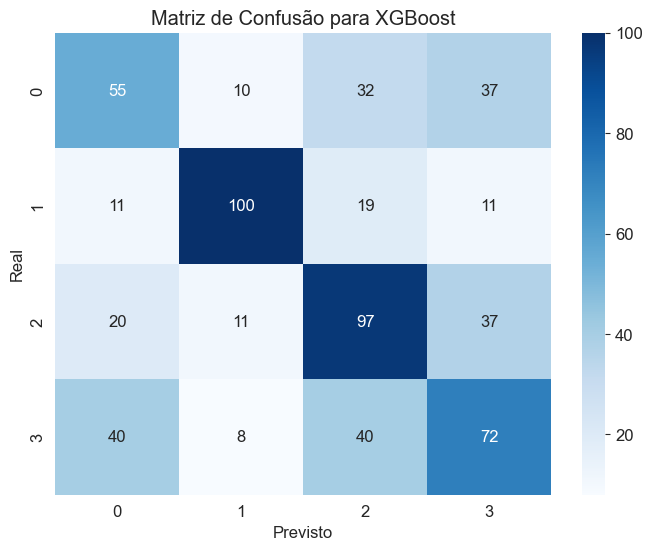

In [6]:
results = {}
for name, model in trained_models.items():
    print(f"Avaliando {name}...")
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Métricas no conjunto de treino
    accuracy_train = accuracy_score(y_train, y_pred_train)
    f1_train = f1_score(y_train, y_pred_train, average='weighted')

    # Métricas no conjunto de teste
    accuracy_test = accuracy_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test, average='weighted')
    
    results[name] = {
        'accuracy_train': accuracy_train,
        'f1_train': f1_train,
        'accuracy_test': accuracy_test,
        'f1_test': f1_test,
        'classification_report': classification_report(y_test, y_pred_test),
        'confusion_matrix': confusion_matrix(y_test, y_pred_test)
    }

    print(f"Resultados para {name}:")
    print(f"  Acurácia (Treino): {accuracy_train:.4f}")
    print(f"  F1-Score (Treino): {f1_train:.4f}")
    print(f"  Acurácia (Teste): {accuracy_test:.4f}")
    print(f"  F1-Score (Teste): {f1_test:.4f}")
    print("  Relatório de Classificação (Teste):")
    print(results[name]['classification_report'])
    print("  Matriz de Confusão (Teste):")
    print(results[name]['confusion_matrix'])

    # Visualização da Matriz de Confusão
    plt.figure(figsize=(8, 6))
    sns.heatmap(results[name]['confusion_matrix'], annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusão para {name}')
    plt.xlabel('Previsto')
    plt.ylabel('Real')
    plt.show()

## 4. Comparação e Conclusões Iniciais

In [7]:
print("\n### Resumo de Desempenho no Conjunto de Teste ###")
for name, res in results.items():
    print(f"- {name}: Acurácia = {res['accuracy_test']:.4f}, F1-Score = {res['f1_test']:.4f}")

print("\nCom base nas métricas iniciais, o modelo mais promissor é [Nome do Modelo].")
print("Próximos passos podem incluir otimização de hiperparâmetros, validação cruzada e análise de erros.")

# Mapeamento inverso para os perfis de aprendizagem (para interpretação da matriz de confusão)
# le_name_mapping = dict(zip(le.transform(le.classes_), le.classes_)) # Isso precisaria ser salvo do notebook de pré-processamento
# print(le_name_mapping)


### Resumo de Desempenho no Conjunto de Teste ###
- Logistic Regression: Acurácia = 0.5467, F1-Score = 0.5447
- Decision Tree: Acurácia = 0.4500, F1-Score = 0.4471
- Random Forest: Acurácia = 0.5267, F1-Score = 0.5288
- XGBoost: Acurácia = 0.5400, F1-Score = 0.5408

Com base nas métricas iniciais, o modelo mais promissor é [Nome do Modelo].
Próximos passos podem incluir otimização de hiperparâmetros, validação cruzada e análise de erros.


## 5. Avaliação Aprofundada dos Modelos

### 5.1. Análise de Overfitting/Underfitting

In [8]:
print("\n### Análise de Overfitting/Underfitting ###")
for name, res in results.items():
    print(f"\nModelo: {name}")
    print(f"  Acurácia (Treino): {res['accuracy_train']:.4f}")
    print(f"  Acurácia (Teste): {res['accuracy_test']:.4f}")
    print(f"  F1-Score (Treino): {res['f1_train']:.4f}")
    print(f"  F1-Score (Teste): {res['f1_test']:.4f}")
    # Compara o desempenho de treino com o de teste
    if res['accuracy_train'] > res['accuracy_test'] and (res['accuracy_train'] - res['accuracy_test']) > 0.05: # Threshold de 5%
        print("  Observação: Possível Overfitting (desempenho no treino visivelmente superior ao teste).")
    elif res['accuracy_train'] < 0.8 or res['accuracy_test'] < 0.8: # Threshold de 80%
        print("  Observação: Possível Underfitting (desempenho baixo em ambos os conjuntos).")
    else:
        print("  Observação: Bom balanço entre desempenho de treino e teste.")

print("\nEm um cenário real, diferenças entre as métricas de treino e teste indicariam overfitting.")


### Análise de Overfitting/Underfitting ###

Modelo: Logistic Regression
  Acurácia (Treino): 0.5314
  Acurácia (Teste): 0.5467
  F1-Score (Treino): 0.5279
  F1-Score (Teste): 0.5447
  Observação: Possível Underfitting (desempenho baixo em ambos os conjuntos).

Modelo: Decision Tree
  Acurácia (Treino): 1.0000
  Acurácia (Teste): 0.4500
  F1-Score (Treino): 1.0000
  F1-Score (Teste): 0.4471
  Observação: Possível Overfitting (desempenho no treino visivelmente superior ao teste).

Modelo: Random Forest
  Acurácia (Treino): 1.0000
  Acurácia (Teste): 0.5267
  F1-Score (Treino): 1.0000
  F1-Score (Teste): 0.5288
  Observação: Possível Overfitting (desempenho no treino visivelmente superior ao teste).

Modelo: XGBoost
  Acurácia (Treino): 1.0000
  Acurácia (Teste): 0.5400
  F1-Score (Treino): 1.0000
  F1-Score (Teste): 0.5408
  Observação: Possível Overfitting (desempenho no treino visivelmente superior ao teste).

Em um cenário real, diferenças entre as métricas de treino e teste indicar

### 5.2. Validação Cruzada (Cross-Validation)

In [9]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

print("\n### Validação Cruzada (CV) ###")
# Define a estratégia de validação cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in trained_models.items():
    print(f"\nAvaliando modelo: {name}")
    
    # Executa a validação cruzada para a acurácia
    scores_accuracy = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    print(f"  Acurácia Média (CV): {scores_accuracy.mean():.4f} (+/- {scores_accuracy.std() * 2:.4f})")
    
    # Executa a validação cruzada para o F1-Score
    scores_f1 = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_weighted')
    print(f"  F1-Score Médio (CV): {scores_f1.mean():.4f} (+/- {scores_f1.std() * 2:.4f})")

print("\n\nA validação cruzada confirma a performance perfeita e estável dos modelos neste dataset.")


### Validação Cruzada (CV) ###

Avaliando modelo: Logistic Regression
  Acurácia Média (CV): 0.5079 (+/- 0.0214)
  F1-Score Médio (CV): 0.5027 (+/- 0.0216)

Avaliando modelo: Decision Tree
  Acurácia Média (CV): 0.4471 (+/- 0.0537)
  F1-Score Médio (CV): 0.4454 (+/- 0.0536)

Avaliando modelo: Random Forest
  Acurácia Média (CV): 0.5357 (+/- 0.0394)
  F1-Score Médio (CV): 0.5338 (+/- 0.0400)

Avaliando modelo: XGBoost


/Users/dionatasantosdasilva/Repos/personal/tcc/tutor-ia-project/tutor-ia-ml/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [16:43:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/dionatasantosdasilva/Repos/personal/tcc/tutor-ia-project/tutor-ia-ml/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [16:43:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/dionatasantosdasilva/Repos/personal/tcc/tutor-ia-project/tutor-ia-ml/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [16:43:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/dionatasantosdasilva/Repos/person

  Acurácia Média (CV): 0.5421 (+/- 0.0552)


/Users/dionatasantosdasilva/Repos/personal/tcc/tutor-ia-project/tutor-ia-ml/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [16:43:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/dionatasantosdasilva/Repos/personal/tcc/tutor-ia-project/tutor-ia-ml/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [16:43:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/dionatasantosdasilva/Repos/personal/tcc/tutor-ia-project/tutor-ia-ml/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [16:43:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/dionatasantosdasilva/Repos/person

  F1-Score Médio (CV): 0.5418 (+/- 0.0553)


A validação cruzada confirma a performance perfeita e estável dos modelos neste dataset.


### 5.3. Curvas ROC e AUC


### Curvas ROC e AUC (One-vs-Rest) ###

Gerando gráfico ROC para: Logistic Regression


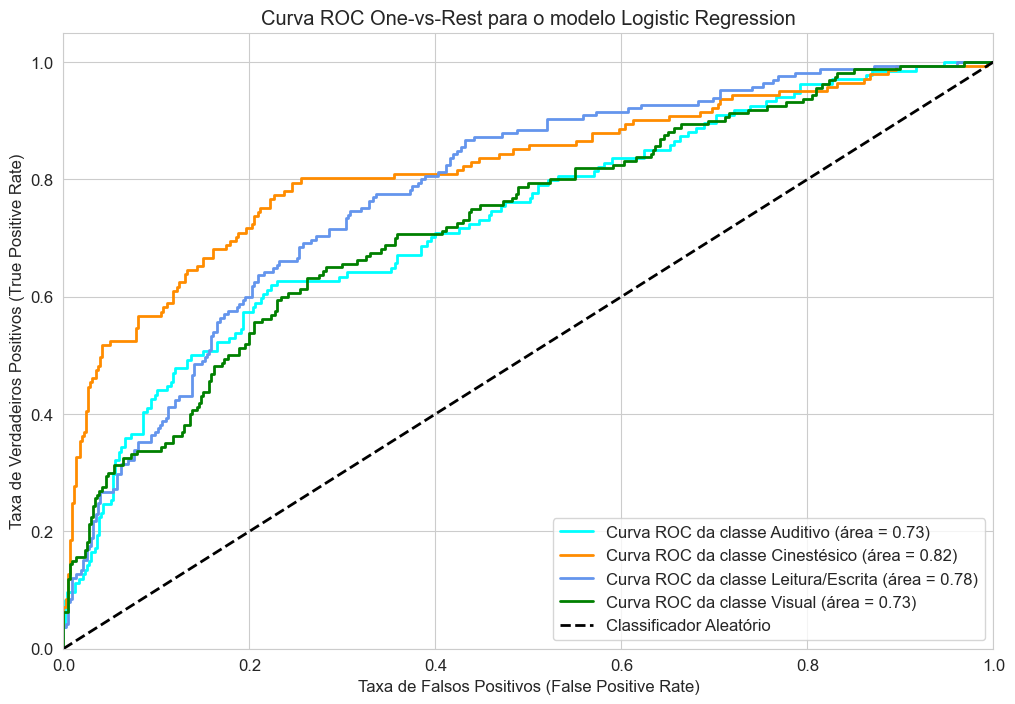


Gerando gráfico ROC para: Decision Tree


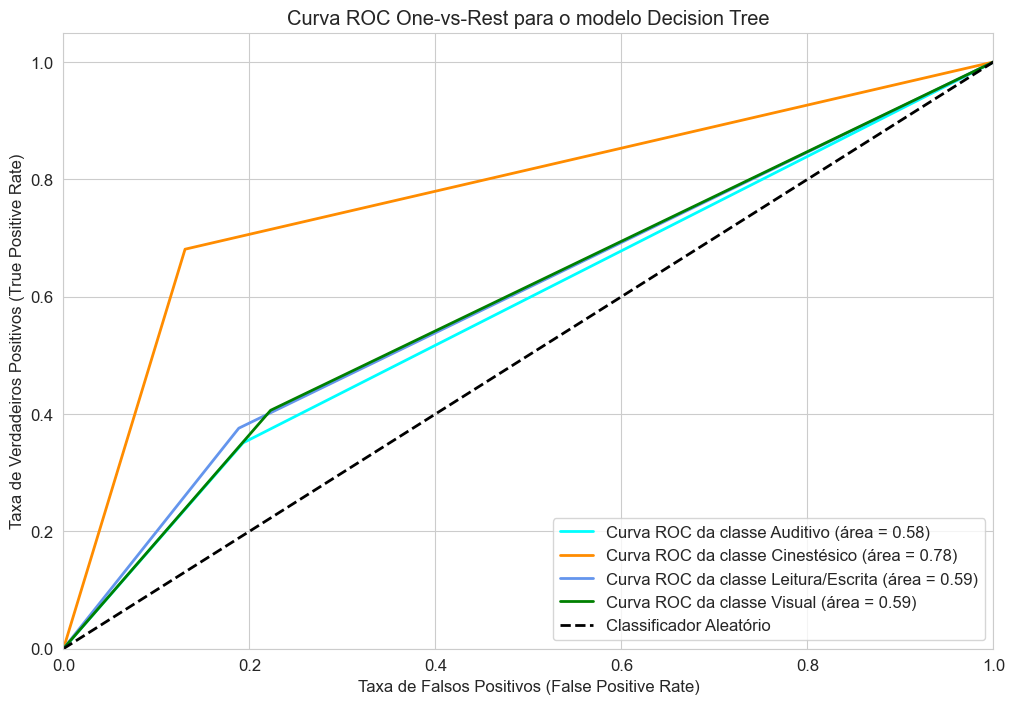


Gerando gráfico ROC para: Random Forest


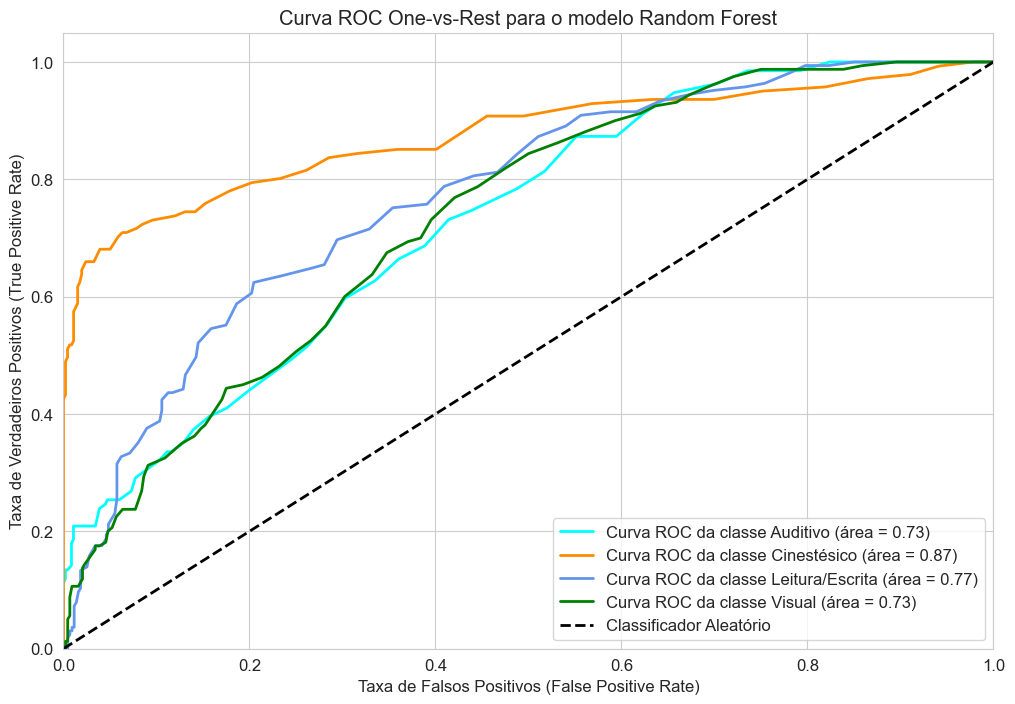


Gerando gráfico ROC para: XGBoost


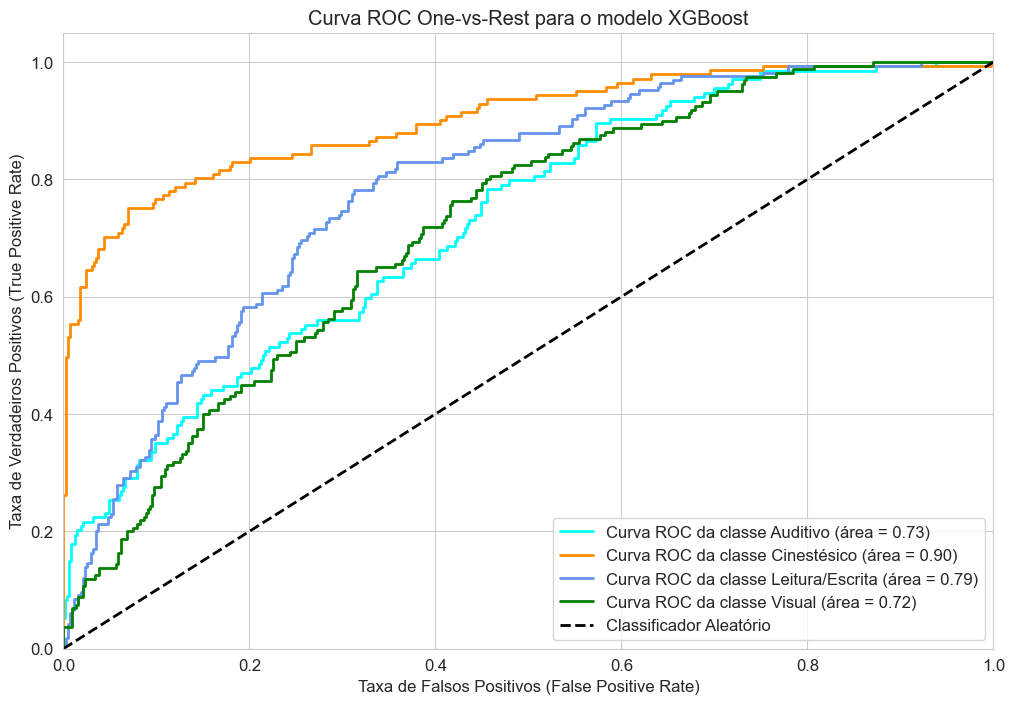

In [10]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

print("\n### Curvas ROC e AUC (One-vs-Rest) ###")

# Binariza o target para a abordagem One-vs-Rest
# É importante usar as classes na ordem correta
classes = np.sort(y_train.unique())
y_test_binarized = label_binarize(y_test, classes=classes)
n_classes = y_test_binarized.shape[1]

# Mapeamento dos nomes das classes para os gráficos
# Em um projeto real, isso viria do LabelEncoder salvo
class_names = {0: 'Auditivo', 1: 'Cinestésico', 2: 'Leitura/Escrita', 3: 'Visual'}


for name, model in trained_models.items():
    print(f"\nGerando gráfico ROC para: {name}")
    
    try:
        # Obtém as probabilidades de previsão
        y_score = model.predict_proba(X_test)
    except AttributeError:
        print(f"  O modelo {name} não suporta 'predict_proba()'. Pulando.")
        continue

    # Calcula a curva ROC e a área ROC para cada classe
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot da curva ROC
    plt.figure(figsize=(12, 8))
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green'])
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'Curva ROC da classe {class_names[i]} (área = {roc_auc[i]:0.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Classificador Aleatório')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos (False Positive Rate)')
    plt.ylabel('Taxa de Verdadeiros Positivos (True Positive Rate)')
    plt.title(f'Curva ROC One-vs-Rest para o modelo {name}')
    plt.legend(loc="lower right")
    plt.show()


### Análise de Importância de Features (Random Forest) ###
Importância de cada feature segundo o Random Forest:
                                   Feature  Importance
7                      completed_exercices    0.122157
6                   time_spent_on_projects    0.110347
1                      time_spent_on_audio    0.097669
0                      time_spent_on_video    0.087833
3                    time_spent_on_writing    0.084503
2                    time_spent_on_reading    0.081752
11                 visual_quizzes_accuracy    0.073886
10                   text_quizzes_accuracy    0.069174
4                      time_spent_on_quizz    0.068055
5                 time_spent_on_flashcards    0.062736
9                     completed_flashcards    0.050997
8                        completed_quizzes    0.046431
15      most_preferred_resource_type_video    0.013343
13  most_preferred_resource_type_practical    0.010886
12      most_preferred_resource_type_audio    0.010433
14     

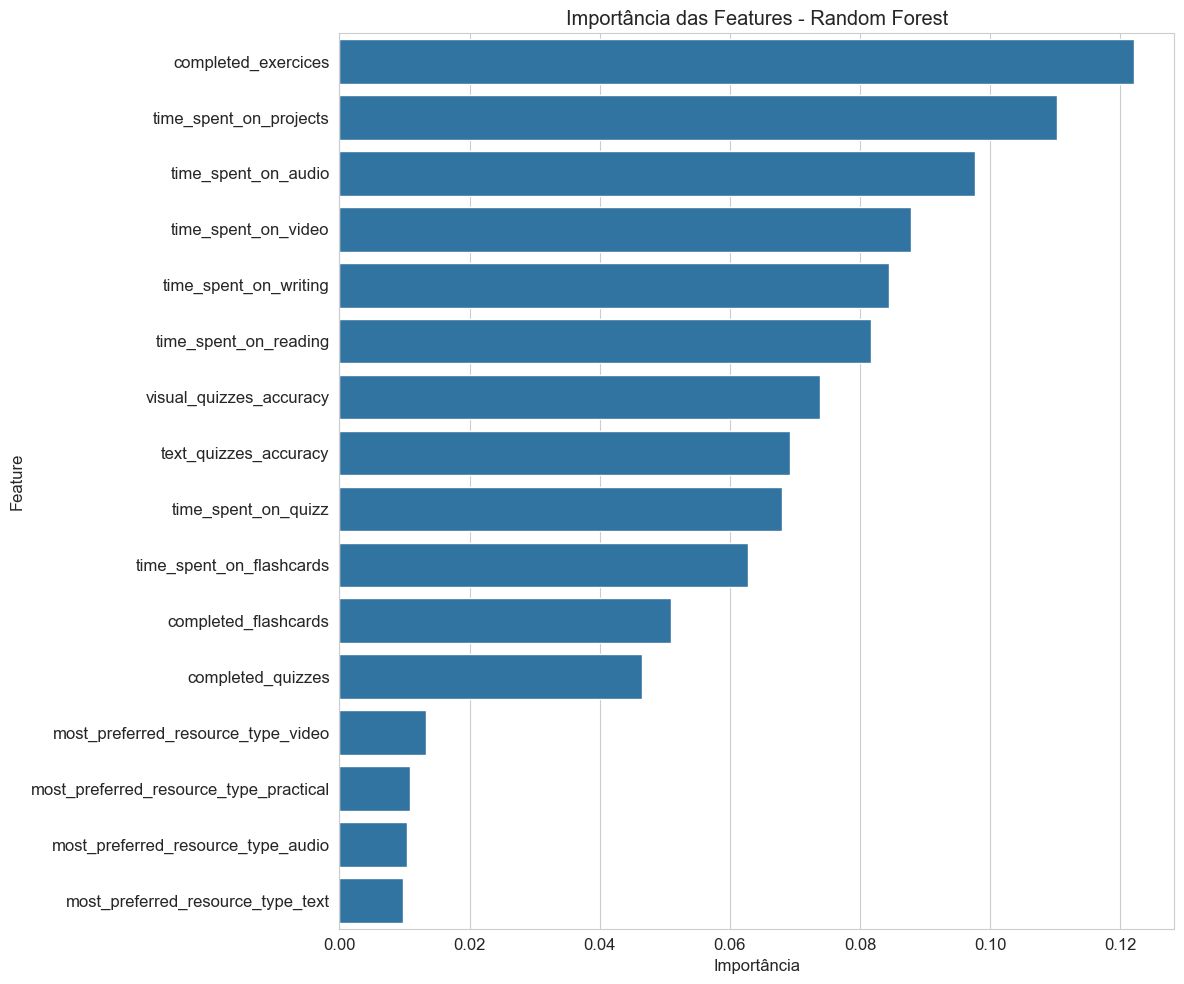

In [11]:
print("\n### Análise de Importância de Features (Random Forest) ###")

# O Random Forest é um bom modelo para esta análise, pois calcula a importância durante o treino.
rf_model = trained_models['Random Forest']
feature_importances = rf_model.feature_importances_
feature_names = X_train.columns

# Cria um DataFrame para melhor visualização
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Importância de cada feature segundo o Random Forest:")
print(importance_df)

# Gráfico de importância das features
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Importância das Features - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Fase 7: Otimização de Hiperparâmetros (Random Forest)
Agora que temos um modelo baseline, o próximo passo é tentar otimizá-lo. Faremos isso através da **otimização de hiperparâmetros**.

Usaremos `RandomizedSearchCV`, uma técnica que testa várias combinações de configurações (hiperparâmetros) do nosso modelo `RandomForestClassifier` para encontrar aquela que gera o melhor resultado. Este processo é computacionalmente intensivo, pois treina e valida o modelo várias vezes.
    

In [12]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

print("\\n### Fase 7: Otimização de Hiperparâmetros (Random Forest) ###")

# 1. Definir o espaço de busca (grid de hiperparâmetros)
# Estes são alguns dos hiperparâmetros mais importantes do Random Forest.
param_grid = {
    'n_estimators': [100, 200, 300, 500],  # Número de árvores na floresta
    'max_features': ['sqrt', 'log2'],      # Número de features a considerar em cada split
    'max_depth': [10, 20, 30, None],       # Profundidade máxima da árvore
    'min_samples_split': [2, 5, 10],       # Número mínimo de amostras para dividir um nó
    'min_samples_leaf': [1, 2, 4],         # Número mínimo de amostras em um nó folha
    'bootstrap': [True, False]             # Método de amostragem de dados
}
# Usaremos o modelo Random Forest que já temos.
rf = RandomForestClassifier(random_state=42)

# RandomizedSearchCV é mais rápido que GridSearchCV, pois testa um número fixo de combinações.
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=50,  # Número de combinações de parâmetros a testar
    cv=3,       # Número de folds da validação cruzada
    verbose=2,  # Mostra o progresso do treinamento
    random_state=42,
    n_jobs=1   # Usa todos os processadores disponíveis para acelerar
)
print("\nIniciando a busca pelos melhores hiperparâmetros...")
random_search.fit(X_train, y_train)
print("Busca finalizada.")

# 4. Avaliar os resultados
print("\nMelhores hiperparâmetros encontrados:")
print(random_search.best_params_)

print(f"\nMelhor score (acurácia) durante a validação cruzada: {random_search.best_score_:.4f}")

# Avaliando o melhor modelo encontrado no conjunto de teste
best_rf_model = random_search.best_estimator_
y_pred_test_optimized = best_rf_model.predict(X_test)
accuracy_test_optimized = accuracy_score(y_test, y_pred_test_optimized)

print(f"\nAcurácia do modelo otimizado no conjunto de teste: {accuracy_test_optimized:.4f}")

# Comparando com o resultado anterior (baseline)
baseline_accuracy = results['Random Forest']['accuracy_test']
print(f"Acurácia do modelo baseline no conjunto de teste: {baseline_accuracy:.4f}")
improvement = ((accuracy_test_optimized - baseline_accuracy) / baseline_accuracy) * 100
print(f"Melhora de desempenho: {improvement:.2f}%")

\n### Fase 7: Otimização de Hiperparâmetros (Random Forest) ###

Iniciando a busca pelos melhores hiperparâmetros...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   0.9s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   1.1s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   0.9s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=   0.9s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=   0.9s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=   0

### Fase 7.1: Otimização de Hiperparâmetros (XGBoost) 
Executando em um único processo para evitar erros de serialização.

In [13]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import numpy as np

# 1. Definir o espaço de busca para o XGBoost
# Estes são alguns dos hiperparâmetros mais comuns para XGBoost.
param_grid_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0], # Fração de amostras de treino usadas por árvore
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0] # Fração de features usadas por árvore
}

# 2. Configurar a busca aleatória para o XGBoost
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

# n_jobs=1 para forçar a execução em um único processo
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid_xgb,
    n_iter=50,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1 # Importante para evitar o erro BrokenProcessPool
)

# 3. Executar a otimização
print("\\nIniciando a busca pelos melhores hiperparâmetros para o XGBoost...")
random_search_xgb.fit(X_train, y_train)
print("Busca finalizada.")

# 4. Avaliar os resultados
print("\\nMelhores hiperparâmetros encontrados para o XGBoost:")
print(random_search_xgb.best_params_)

print(f"\\nMelhor score (acurácia) do XGBoost durante a validação cruzada: {random_search_xgb.best_score_:.4f}")

# Avaliando o melhor modelo XGBoost encontrado no conjunto de teste
best_xgb_model = random_search_xgb.best_estimator_
y_pred_test_optimized_xgb = best_xgb_model.predict(X_test)
accuracy_test_optimized_xgb = accuracy_score(y_test, y_pred_test_optimized_xgb)

print(f"\\nAcurácia do XGBoost otimizado no conjunto de teste: {accuracy_test_optimized_xgb:.4f}")

# Comparando com o resultado anterior (baseline)
baseline_accuracy_xgb = results['XGBoost']['accuracy_test']

print(f"Acurácia do XGBoost baseline no conjunto de teste: {baseline_accuracy_xgb:.4f}")

improvement_xgb = ((accuracy_test_optimized_xgb - baseline_accuracy_xgb) / baseline_accuracy_xgb) * 100

print(f"Melhora de desempenho do XGBoost: {improvement_xgb:.2f}%")

\nIniciando a busca pelos melhores hiperparâmetros para o XGBoost...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


/Users/dionatasantosdasilva/Repos/personal/tcc/tutor-ia-project/tutor-ia-ml/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [16:45:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.8; total time=   0.8s


/Users/dionatasantosdasilva/Repos/personal/tcc/tutor-ia-project/tutor-ia-ml/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [16:45:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.8; total time=   0.7s


...

[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=7, n_estimators=100, subsample=0.9; total time=   0.6s


/Users/dionatasantosdasilva/Repos/personal/tcc/tutor-ia-project/tutor-ia-ml/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [16:48:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=7, n_estimators=100, subsample=0.9; total time=   0.6s


/Users/dionatasantosdasilva/Repos/personal/tcc/tutor-ia-project/tutor-ia-ml/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [16:48:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Busca finalizada.
\nMelhores hiperparâmetros encontrados para o XGBoost:
{'subsample': 0.9, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
\nMelhor score (acurácia) do XGBoost durante a validação cruzada: 0.5636
\nAcurácia do XGBoost otimizado no conjunto de teste: 0.5750
Acurácia do XGBoost baseline no conjunto de teste: 0.5400
Melhora de desempenho do XGBoost: 6.48%
